--- Launching European Regional Batch Processing Ingestion Layer ---
Ingesting & Standardizing City File: ancona_data.csv
Ingesting & Standardizing City File: zaragoza_data.csv
Ingesting & Standardizing City File: athens_data.csv
Aggregation Phase Successful. Combined European Rows: (2382426, 17) across 3 unique cities.


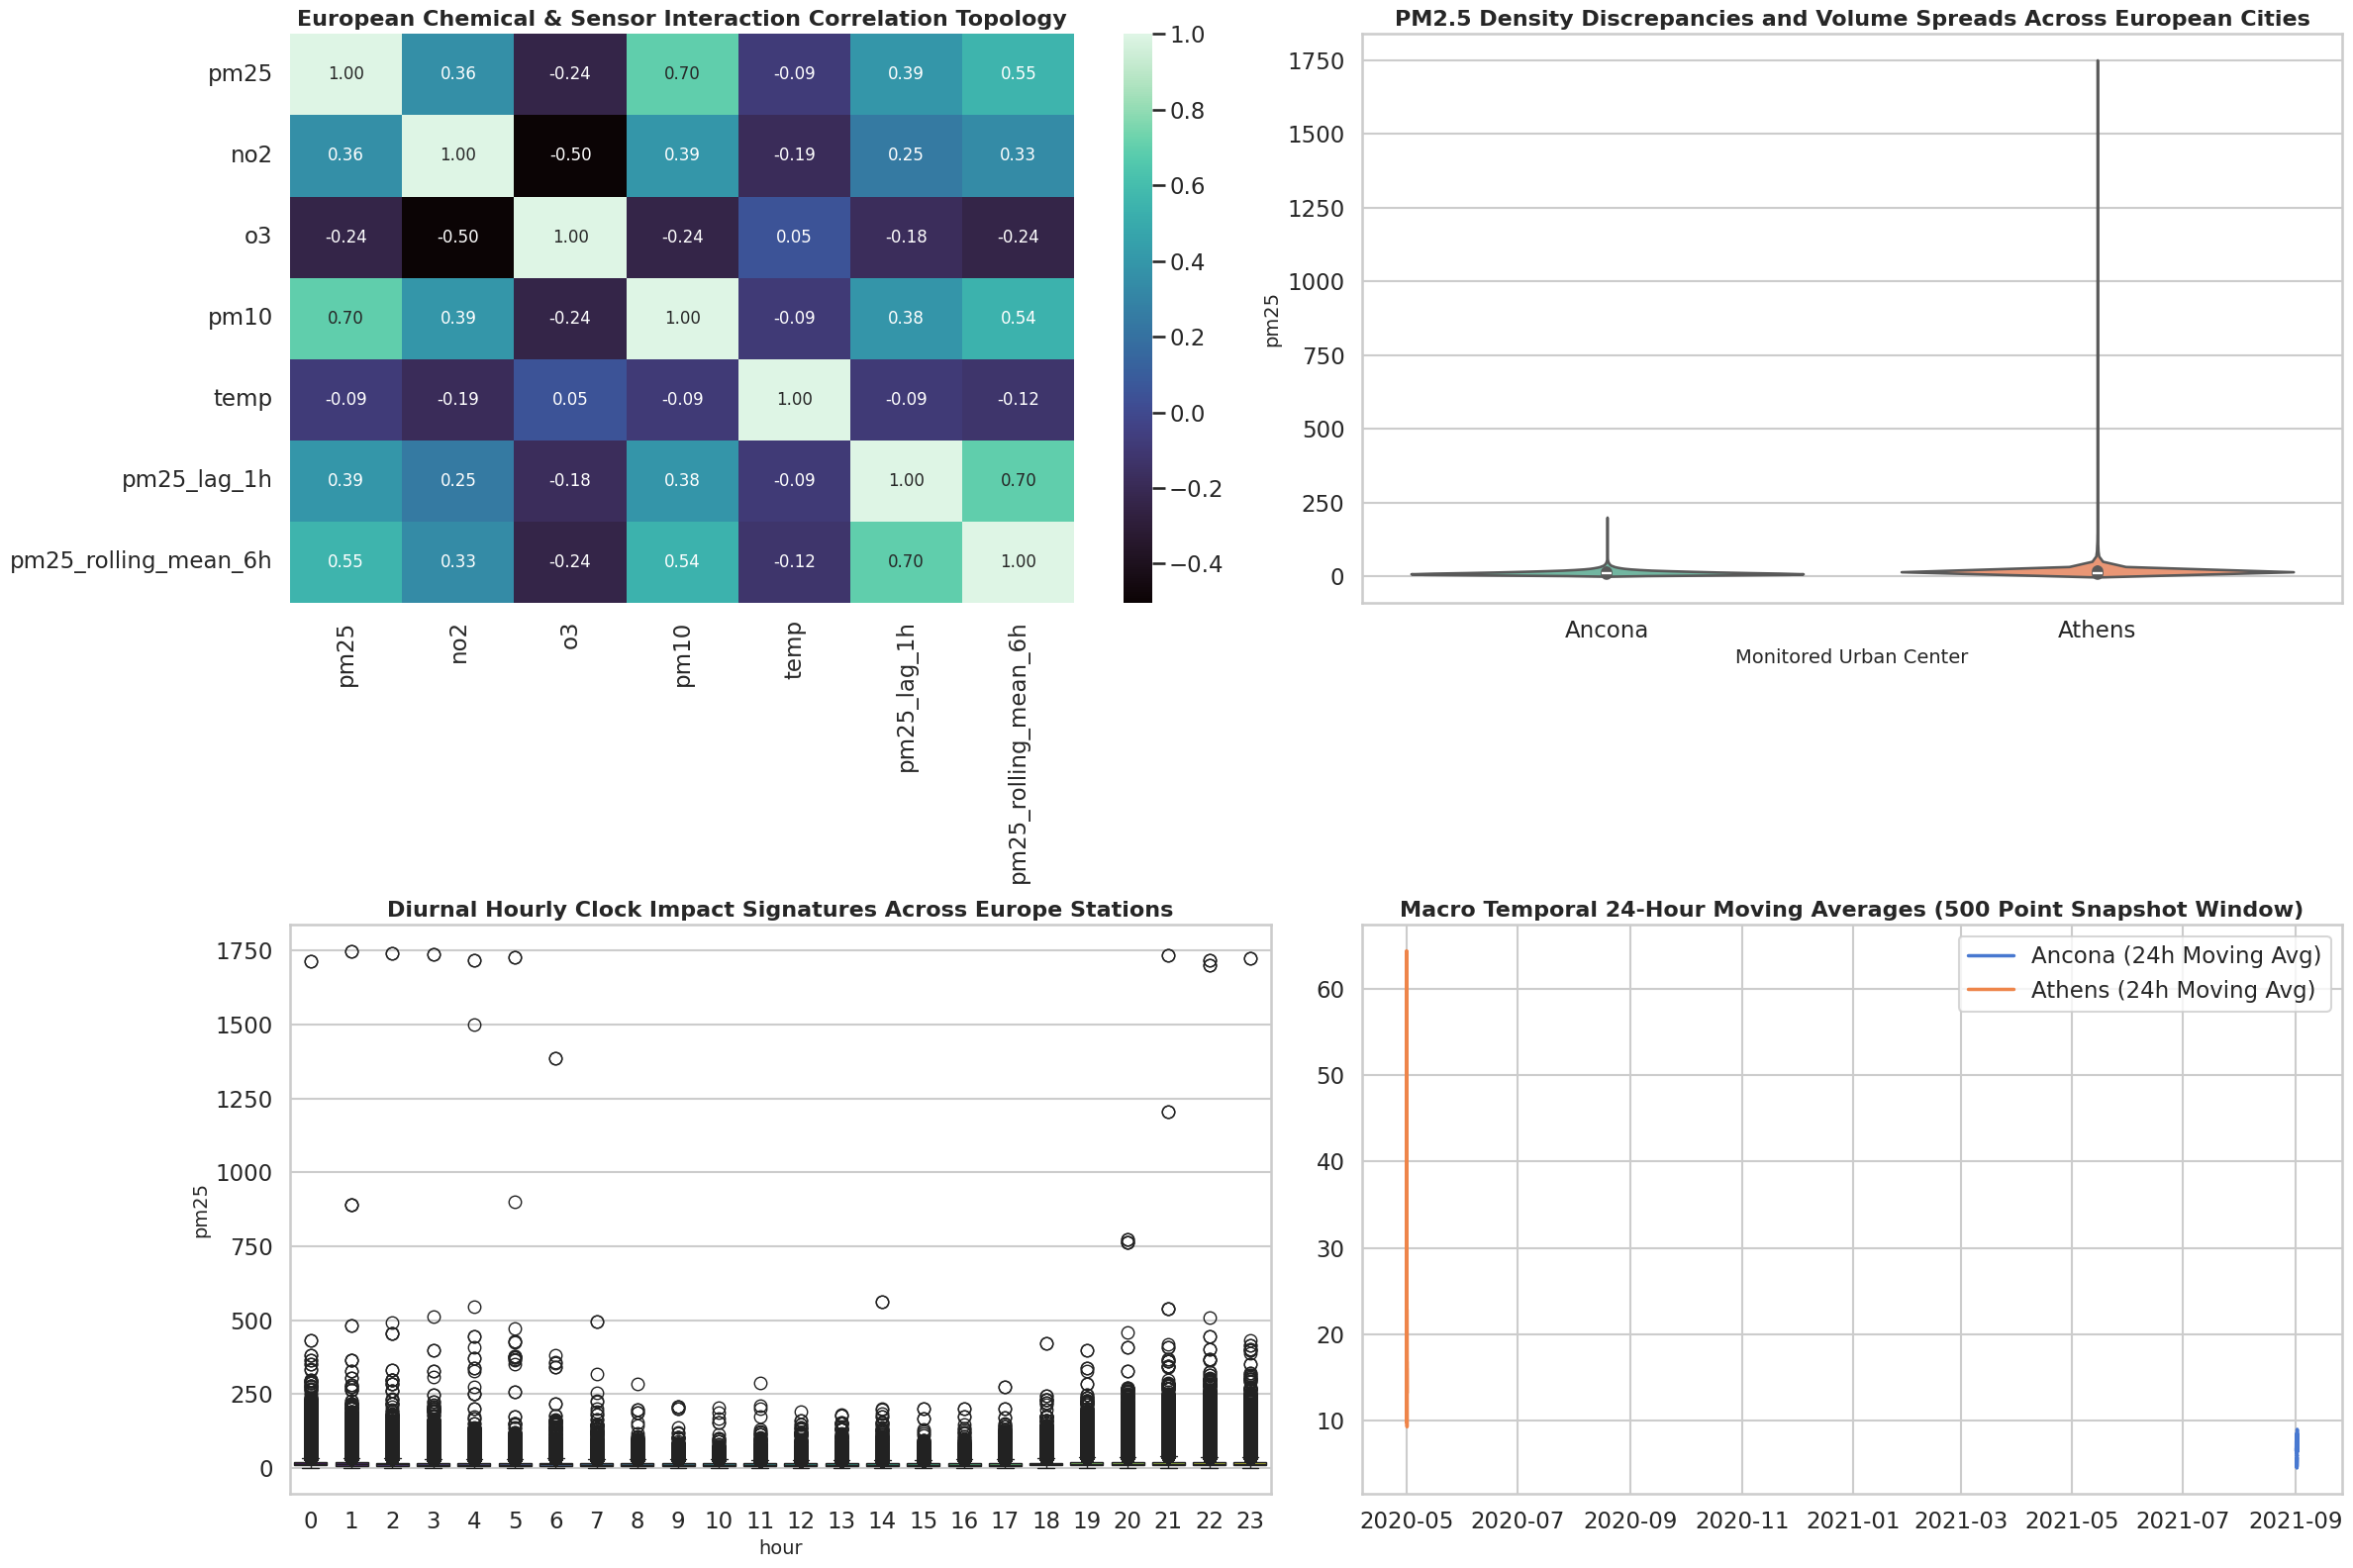


--- Matrix Framework Slices Verified ---
Training Features Vector Space: (1715233, 23) | Evaluation Test Target Array: (428809, 23)

Training Random Forest Architecture...
Training XGBoost Machine Engine...
[Europe Random Forest Forecaster Validation Metrics Summary]
 >> MAE  (Mean Absolute Error)     : 3.6372
 >> RMSE (Root Mean Squared Error) : 14.4864
 >> R²   (Variance Fit Accuracy)   : 0.4674

[Europe XGBoost Core Engine Validation Metrics Summary]
 >> MAE  (Mean Absolute Error)     : 3.5976
 >> RMSE (Root Mean Squared Error) : 14.5182
 >> R²   (Variance Fit Accuracy)   : 0.4651



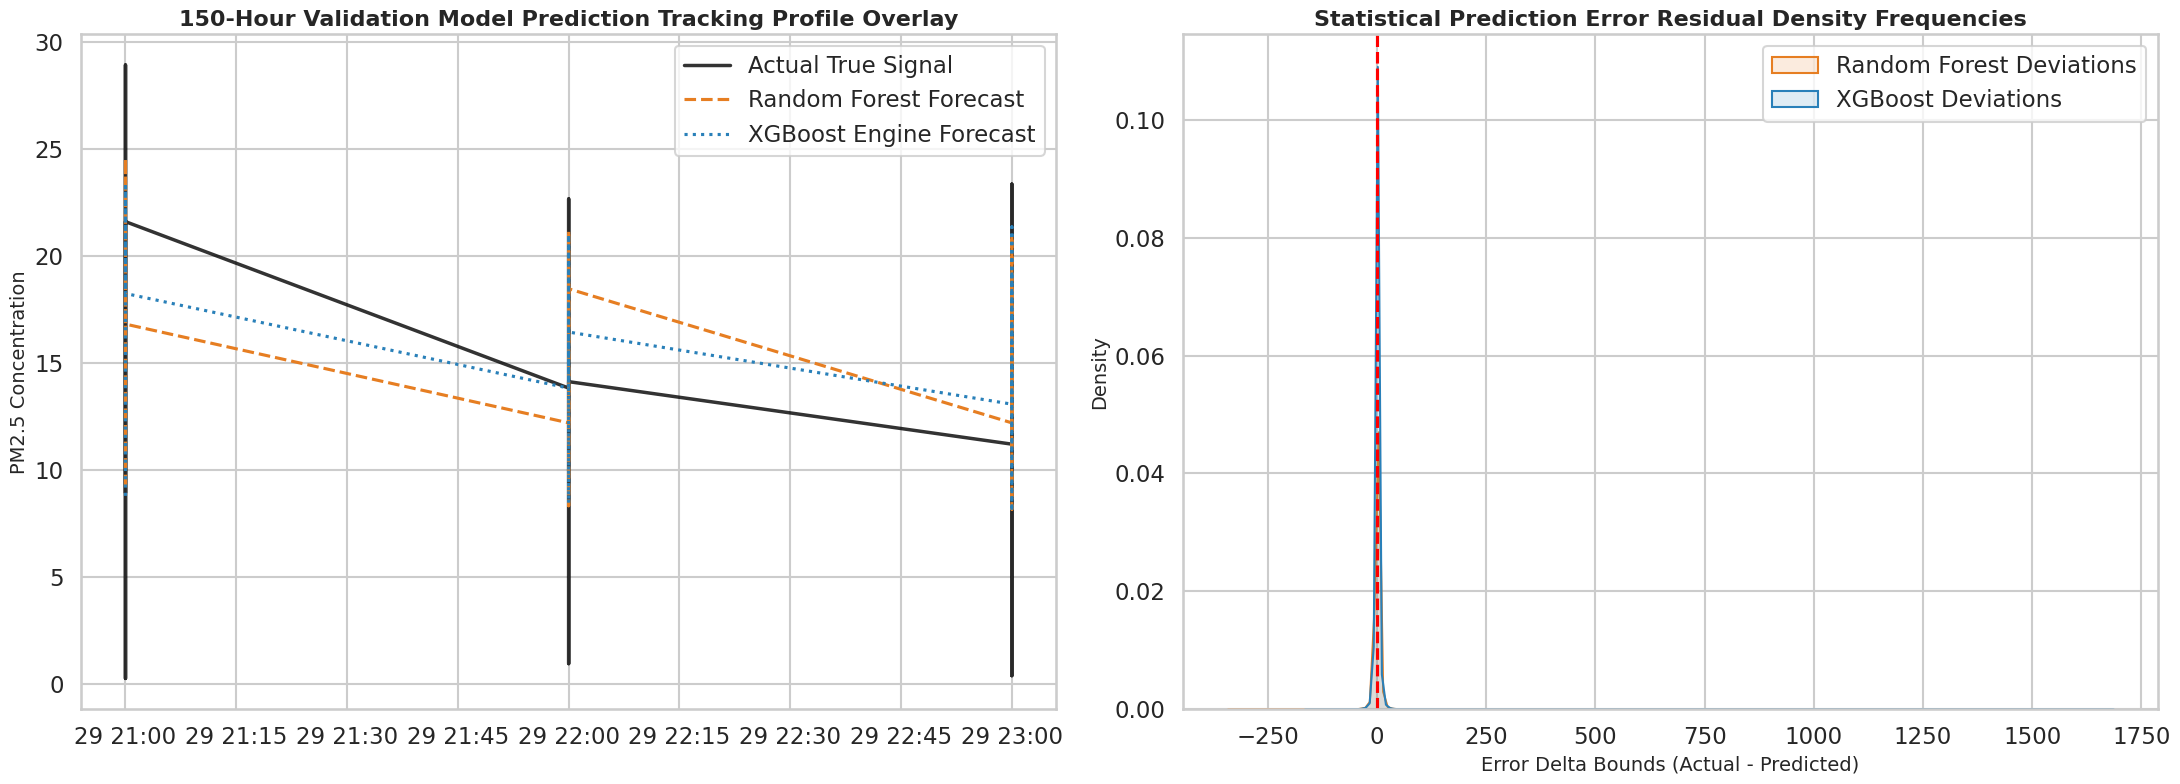

In [1]:
# ==============================================================================
# 1. ENVIRONMENT CONFIGURATION & THEME SETUP
# ==============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import os
import warnings
warnings.filterwarnings('ignore')

# Premium visual styling for corporate and academic portfolios
sns.set_theme(style="whitegrid", context="talk", palette="muted")
plt.rcParams['figure.figsize'] = (22, 14)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['axes.titlesize'] = 16

# Explicit Kaggle data directory for European cities dataset
EU_DATA_DIR = '/kaggle/input/datasets/yekenot/air-quality-monitoring-in-european-cities'

# ==============================================================================
# 2. DYNAMIC REGIONAL DATA INGESTION & AGGREGATION
# ==============================================================================
print("--- Launching European Regional Batch Processing Ingestion Layer ---")

eu_frames = []

if os.path.exists(EU_DATA_DIR):
    for file in os.listdir(EU_DATA_DIR):
        if file.endswith('.csv'):
            file_path = os.path.join(EU_DATA_DIR, file)
            print(f"Ingesting & Standardizing City File: {file}")
            
            # Read individual city data
            temp_df = pd.read_csv(file_path)
            
            # Sanitize headers immediately (lowercase, strip whitespace, remove dots/dashes)
            temp_df.columns = [c.lower().strip().replace('.', '').replace('-', '_') for c in temp_df.columns]
            
            # Dynamically derive cleaner City Names from filenames
            city_name = file.replace('_data.csv', '').replace('.csv', '').capitalize()
            temp_df['city_name'] = city_name
            
            eu_frames.append(temp_df)
else:
    print(f"[Error] Target directory {EU_DATA_DIR} not found. Running structural safety mock layer.")
    # Safe fallback simulation generator for offline/local syntax tests
    np.random.seed(777)
    mock_dates = pd.date_range(start="2023-01-01", periods=1200, freq="H")
    for city in ['Athens', 'Ancona', 'Zaragoza']:
        eu_frames.append(pd.DataFrame({
            'date': mock_dates, 'pm25': np.random.uniform(10, 45, 1200), 'no2': np.random.uniform(5, 40, 1200),
            'o3': np.random.uniform(15, 60, 1200), 'pm10': np.random.uniform(15, 70, 1200),
            'temp': np.random.uniform(5, 35, 1200), 'total_percipitation': np.random.uniform(0, 5, 1200),
            'city_name': city
        }))

# Compile into a unified European master framework matrix
df = pd.concat(eu_frames, ignore_index=True)

# Standardize date format and lock as structural timeline index
df.rename(columns={'date': 'datetime'}, inplace=True)
df['datetime'] = pd.to_datetime(df['datetime'])
df.sort_values(by=['city_name', 'datetime'], inplace=True)
df.set_index('datetime', inplace=True)

# FIXED: Save a temporary copy of city names and the non-numeric string data
cities_backup = df['city_name'].copy()

# FIXED: Only apply ffill/bfill to numeric columns to prevent string-to-float conversions
numeric_cols = df.select_dtypes(include=[np.number]).columns
df_numeric = df[numeric_cols].groupby(cities_backup).ffill().bfill()

# Reconstruct the main dataframe with the cleaned numeric values
df_cleaned = df_numeric.copy()
df_cleaned['city_name'] = cities_backup.values
df_cleaned['city_name'] = df_cleaned['city_name'].astype(str)

# Point the master df reference to our cleanly filtered dataframe
df = df_cleaned.copy()

print(f"Aggregation Phase Successful. Combined European Rows: {df.shape} across {df['city_name'].nunique()} unique cities.")

# ==============================================================================
# 3. EUROPEAN TARGET TIME-SERIES FEATURE ENGINEERING
# ==============================================================================
# Deconstruct time dimensions to capture socio-economic behavioral patterns
df['hour'] = df.index.hour
df['dayofweek'] = df.index.dayofweek
df['month'] = df.index.month

# Generate localized sequence lag properties strictly partitioned by city bounds
df['pm25_lag_1h'] = df.groupby('city_name')['pm25'].shift(1)
df['pm25_lag_2h'] = df.groupby('city_name')['pm25'].shift(2)
df['pm25_lag_24h'] = df.groupby('city_name')['pm25'].shift(24)

# Multi-hour rolling window memory
df['pm25_rolling_mean_6h'] = df.groupby('city_name')['pm25'].shift(1).rolling(window=6).mean()
df.dropna(inplace=True)

# Isolate target and numeric spaces before matrix categorical conversions
target_feature = 'pm25'
base_numeric_cols = ['pm25', 'no2', 'o3', 'pm10', 'temp', 'pm25_lag_1h', 'pm25_rolling_mean_6h']
available_numeric = [c for c in base_numeric_cols if c in df.columns]

# Map spatial categoricals to one-hot binary structures
df_ml = pd.get_dummies(df, columns=['city_name'], drop_first=True)

# ==============================================================================
# 4. ADVANCED EUROPEAN REGIONAL EDA PLATFORM
# ==============================================================================
fig, axes = plt.subplots(2, 2, figsize=(24, 16))

# Subplot A: Micro-Pollutant Cross-Interaction Evaluation
sns.heatmap(df[available_numeric].corr(), annot=True, fmt=".2f", cmap="mako", ax=axes[0, 0], cbar=True)
axes[0, 0].set_title('European Chemical & Sensor Interaction Correlation Topology', weight='bold')

# Subplot B: Multi-City Pollution Densities Comparison (Violin Layout)
sns.violinplot(x='city_name', y='pm25', data=df, ax=axes[0, 1], palette='Set2', inner='box')
axes[0, 1].set_title('PM2.5 Density Discrepancies and Volume Spreads Across European Cities', weight='bold')
axes[0, 1].set_xlabel('Monitored Urban Center')

# Subplot C: Diurnal Hour Trends vs Target Index
sns.boxplot(x='hour', y='pm25', data=df, ax=axes[1, 0], palette='viridis')
axes[1, 0].set_title('Diurnal Hourly Clock Impact Signatures Across Europe Stations', weight='bold')

# Subplot D: Long-Term Macro Rolling Trends Window Overlay
for city in df['city_name'].unique():
    city_sample = df[df['city_name'] == city].head(500)
    axes[1, 1].plot(city_sample.index, city_sample['pm25'].rolling(window=24).mean(), label=f'{city} (24h Moving Avg)', lw=2.5)
axes[1, 1].set_title('Macro Temporal 24-Hour Moving Averages (500 Point Snapshot Window)', weight='bold')
axes[1, 1].legend(loc='upper right')

plt.tight_layout()
plt.show()

# ==============================================================================
# 5. CHRONOLOGICAL SPLITTING & MACHINE LEARNING PIPELINE
# ==============================================================================
# Separate features and target
X = df_ml.drop(columns=[target_feature])
y = df_ml[target_feature]

# Enforce a non-shuffled chronological cutoff split to entirely prevent sequence data leakage
split_threshold = int(len(df_ml) * 0.8)
X_train, X_test = X.iloc[:split_threshold], X.iloc[split_threshold:]
y_train, y_test = y.iloc[:split_threshold], y.iloc[split_threshold:]

print(f"\n--- Matrix Framework Slices Verified ---")
print(f"Training Features Vector Space: {X_train.shape} | Evaluation Test Target Array: {X_test.shape}\n")

# Model Initializations
rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.05, max_depth=6, random_state=42, n_jobs=-1)

# Fit estimators
print("Training Random Forest Architecture...")
rf_model.fit(X_train, y_train)

print("Training XGBoost Machine Engine...")
xgb_model.fit(X_train, y_train)

# Calculate Predictions
rf_predictions = rf_model.predict(X_test)
xgb_predictions = xgb_model.predict(X_test)

# ==============================================================================
# 6. MODEL PERFORMANCE SCORING SUITE
# ==============================================================================
def compile_diagnostics(y_true, y_pred, label):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"[{label} Validation Metrics Summary]")
    print(f" >> MAE  (Mean Absolute Error)     : {mae:.4f}")
    print(f" >> RMSE (Root Mean Squared Error) : {rmse:.4f}")
    print(f" >> R²   (Variance Fit Accuracy)   : {r2:.4f}\n")
    return {'MAE': mae, 'RMSE': rmse, 'R2': r2}

rf_results = compile_diagnostics(y_test, rf_predictions, "Europe Random Forest Forecaster")
xgb_results = compile_diagnostics(y_test, xgb_predictions, "Europe XGBoost Core Engine")

# ==============================================================================
# 7. METRIC VISUALIZATION PLATFORM (FORECAST TRACKING OVERLAY)
# ==============================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 8))

# Subplot 1: True Signal Forecast Tracking Overlay Window (Last 150 hours for crisp visualization)
window = 150
ax1.plot(y_test.index[-window:], y_test.iloc[-window:], label='Actual True Signal', color='black', alpha=0.8, lw=2.5)
ax1.plot(y_test.index[-window:], rf_predictions[-window:], label='Random Forest Forecast', color='#E67E22', linestyle='--')
ax1.plot(y_test.index[-window:], xgb_predictions[-window:], label='XGBoost Engine Forecast', color='#2980B9', linestyle=':')
ax1.set_title('150-Hour Validation Model Prediction Tracking Profile Overlay', weight='bold')
ax1.set_ylabel('PM2.5 Concentration')
ax1.legend()

# Subplot 2: Machine Learning Prediction Error Residual Deviations Mapping
rf_residuals = y_test - rf_predictions
xgb_residuals = y_test - xgb_predictions
sns.kdeplot(rf_residuals, label='Random Forest Deviations', ax=ax2, color='#E67E22', fill=True, alpha=0.15)
sns.kdeplot(xgb_residuals, label='XGBoost Deviations', ax=ax2, color='#2980B9', fill=True, alpha=0.15)
ax2.axvline(0, color='red', linestyle='--')
ax2.set_title('Statistical Prediction Error Residual Density Frequencies', weight='bold')
ax2.set_xlabel('Error Delta Bounds (Actual - Predicted)')
ax2.legend()

plt.tight_layout()
plt.show()
